In [1]:
#Importing libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading dataset
dataset=load_dataset("lukebarousse/data_jobs")
df=dataset['train'].to_pandas()

#Cleaning data
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [24]:
df_DA_IND=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='India')].copy()
df_DA_IND=df_DA_IND.dropna(subset=['salary_year_avg'])
df_DA_IND=df_DA_IND.explode('job_skills')

In [ ]:
df_DA_IND=df_DA_IND.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)

df_DA_IND=df_DA_IND.rename(columns={'count':'skill_count','median':'median_salary'})

tot_skill_count=len(df_DA_IND)

df_DA_IND['skill_percent']=df_DA_IND['skill_count']/tot_skill_count * 100



In [29]:
skill_perc_limit=10

df_DA_skill_demand=df_DA_IND[df_DA_IND['skill_percent']>skill_perc_limit]


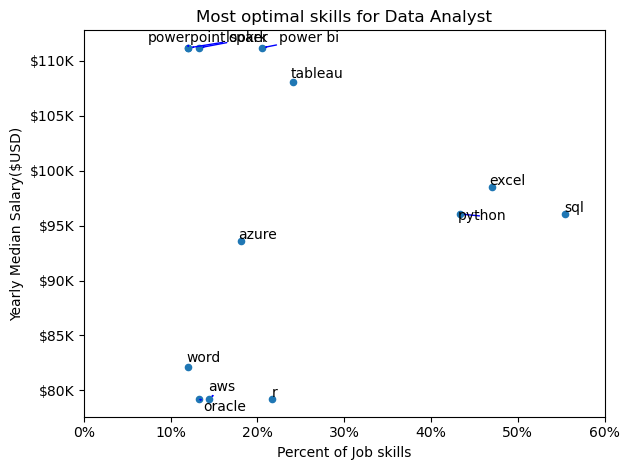

In [45]:
from adjustText import adjust_text
df_DA_skill_demand.plot(kind='scatter',x='skill_percent',y='median_salary')

texts=[]
for i,txt in enumerate(df_DA_skill_demand.index):
    texts.append(plt.text(df_DA_skill_demand['skill_percent'].iloc[i],df_DA_skill_demand['median_salary'].iloc[i], txt))
adjust_text(texts,arrowprops=dict(arrowstyle='->',color='blue'))
#adjust the texts in the graph without any overlsppings of the labels

ax=plt.gca()
#gca=> Get Current Axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}K'))
#sets the current y axis as $_y_K

plt.title('Most optimal skills for Data Analyst')
plt.xlabel('Percent of Job skills')
plt.ylabel('Yearly Median Salary($USD)')
plt.xlim(0,60)
plt.tight_layout()
plt.show()